In [1]:
!pip install xgboost shap -q
print("Done!")

Done!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from xgboost import XGBClassifier
from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Shape: (7043, 21)

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyC

In [4]:
# Fix TotalCharges (some values are blank spaces — not real numbers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

# Remove customer ID column (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn column: Yes = 1, No = 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Cleaned shape:", df.shape)
print("Churn values:", df['Churn'].value_counts().to_dict())

Missing TotalCharges: 11
Cleaned shape: (7043, 20)
Churn values: {0: 5174, 1: 1869}


In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns to encode:", cat_cols)

# Binary columns (Yes/No) → encode as 1/0
binary_cols = [c for c in cat_cols if df[c].nunique() == 2]
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Multi-value columns → one-hot encode
multi_cols = [c for c in cat_cols if df[c].nunique() > 2]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Ready for modelling!")

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)
Ready for modelling!


In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps same churn ratio in both sets
)

# Scale the numerical columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Training rows : {X_train.shape[0]:,}")
print(f"Testing rows  : {X_test.shape[0]:,}")
print(f"Features      : {X_train.shape[1]}")

Training rows : 5,634
Testing rows  : 1,409
Features      : 30


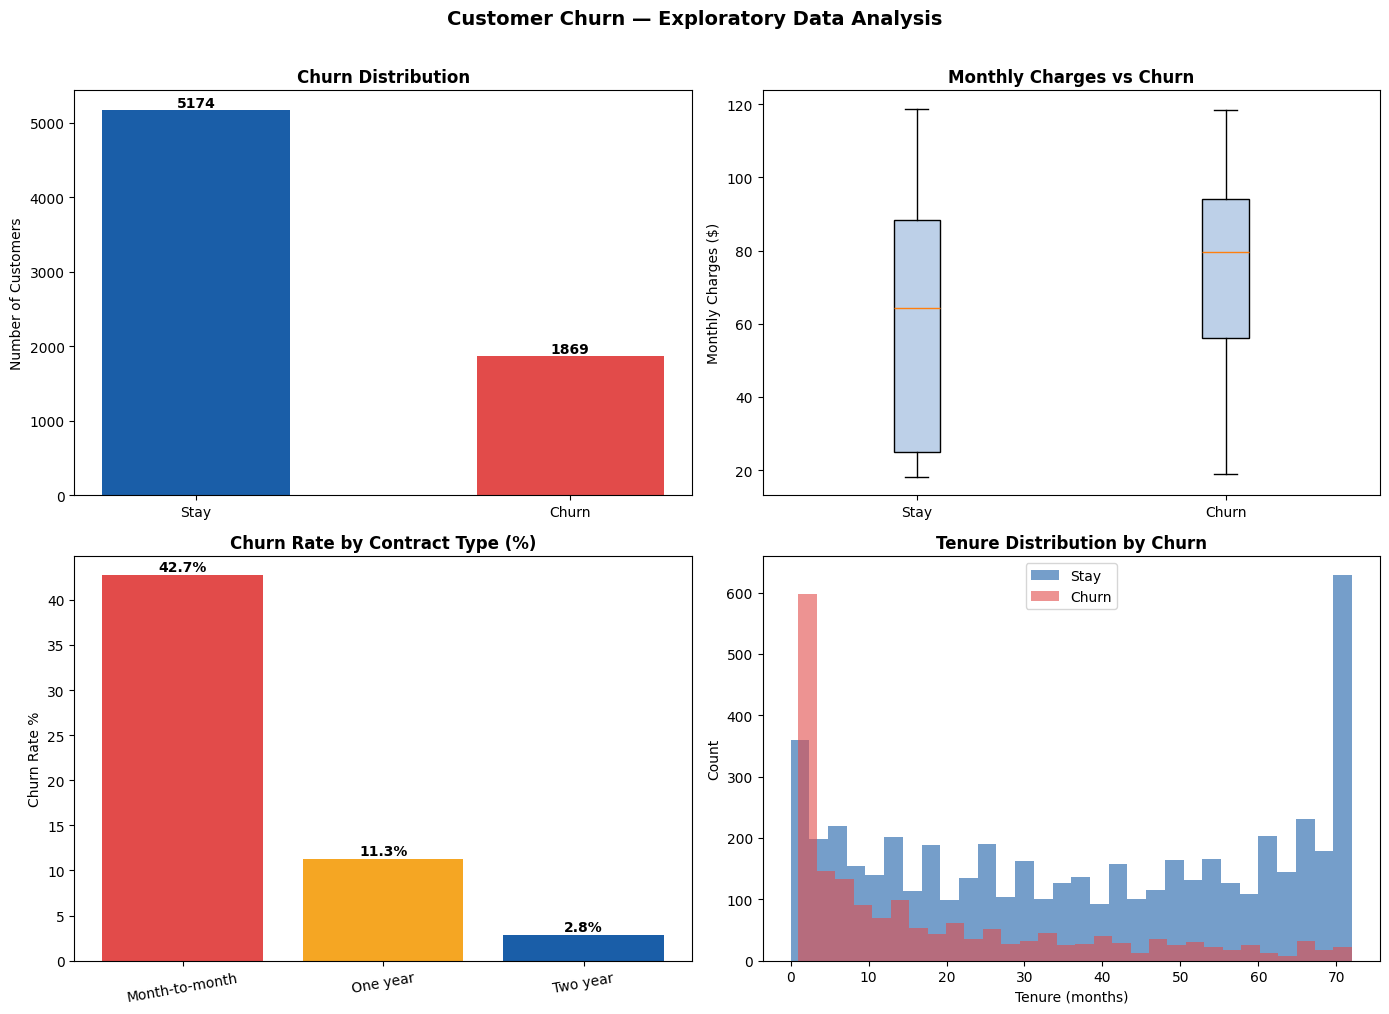

EDA Key Findings:
  Total customers   : 7,043
  Overall churn rate: 26.5%
  Month-to-month churn rate: 42.7%
  Two-year contract churn rate: 2.8%


In [20]:
# ── EDA: 4 charts in one figure ──────────────────────────
raw_eda = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw_eda['TotalCharges'] = pd.to_numeric(raw_eda['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Churn distribution (bar)
churn_counts = raw_eda['Churn'].value_counts()
axes[0,0].bar(['Stay', 'Churn'], churn_counts.values,
              color=['#1A5EA8', '#E24B4A'], width=0.5)
axes[0,0].set_title('Churn Distribution', fontweight='bold')
axes[0,0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 40, str(v), ha='center', fontweight='bold')

# Chart 2 — Monthly charges vs churn (boxplot)
axes[0,1].boxplot(
    [raw_eda[raw_eda['Churn']=='No']['MonthlyCharges'],
     raw_eda[raw_eda['Churn']=='Yes']['MonthlyCharges']],
    labels=['Stay', 'Churn'],
    patch_artist=True,
    boxprops=dict(facecolor='#BDD0E8')
)
axes[0,1].set_title('Monthly Charges vs Churn', fontweight='bold')
axes[0,1].set_ylabel('Monthly Charges ($)')

# Chart 3 — Churn rate by contract type (bar)
churn_by_contract = raw_eda.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)
bars = axes[1,0].bar(churn_by_contract.index,
                     churn_by_contract.values,
                     color=['#E24B4A', '#F5A623', '#1A5EA8'])
axes[1,0].set_title('Churn Rate by Contract Type (%)', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate %')
axes[1,0].set_xticklabels(churn_by_contract.index, rotation=10)
for bar, v in zip(bars, churn_by_contract.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 4 — Tenure distribution by churn (histogram)
axes[1,1].hist(raw_eda[raw_eda['Churn']=='No']['tenure'],
               bins=30, alpha=0.6, label='Stay', color='#1A5EA8')
axes[1,1].hist(raw_eda[raw_eda['Churn']=='Yes']['tenure'],
               bins=30, alpha=0.6, label='Churn', color='#E24B4A')
axes[1,1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[1,1].set_xlabel('Tenure (months)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.suptitle('Customer Churn — Exploratory Data Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

print("EDA Key Findings:")
print(f"  Total customers   : {len(raw_eda):,}")
print(f"  Overall churn rate: {(raw_eda['Churn']=='Yes').mean()*100:.1f}%")
print(f"  Month-to-month churn rate: {churn_by_contract['Month-to-month']:.1f}%")
print(f"  Two-year contract churn rate: {churn_by_contract['Two year']:.1f}%")

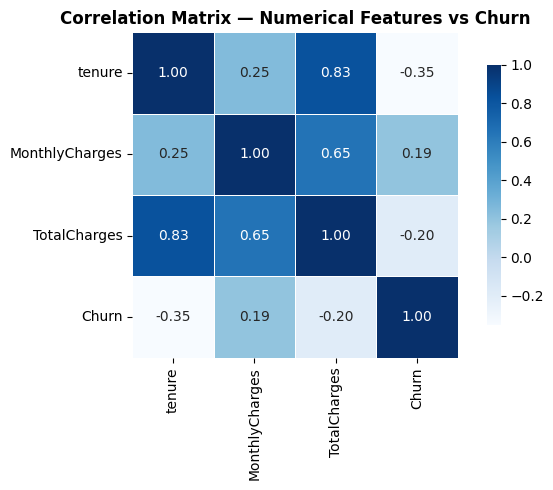

Correlation with Churn:
  Tenure         : -0.352  → longer tenure = less likely to churn
  MonthlyCharges : 0.193  → higher charges = more likely to churn
  TotalCharges   : -0.199  → total spend negatively correlated with churn


In [21]:
# ── Correlation heatmap ───────────────────────────────────
num_data = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()
corr = num_data.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f',
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features vs Churn',
          fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Correlation with Churn:")
print(f"  Tenure         : {corr.loc['tenure','Churn']:.3f}  → longer tenure = less likely to churn")
print(f"  MonthlyCharges : {corr.loc['MonthlyCharges','Churn']:.3f}  → higher charges = more likely to churn")
print(f"  TotalCharges   : {corr.loc['TotalCharges','Churn']:.3f}  → total spend negatively correlated with churn")

In [7]:
raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce')

churned     = raw[raw['Churn'] == 'Yes']['MonthlyCharges']
not_churned = raw[raw['Churn'] == 'No']['MonthlyCharges']

t_stat, p_val = stats.ttest_ind(churned, not_churned)

print("=" * 50)
print("HYPOTHESIS TEST 1: Monthly Charges vs Churn")
print("=" * 50)
print(f"Churned avg monthly charge  : ${churned.mean():.2f}")
print(f"Retained avg monthly charge : ${not_churned.mean():.2f}")
print(f"T-statistic : {t_stat:.3f}")
print(f"P-value     : {p_val:.6f}")
if p_val < 0.05:
    diff = ((churned.mean() - not_churned.mean()) / not_churned.mean()) * 100
    print(f"\nRESULT: SIGNIFICANT (p < 0.05)")
    print(f"Churned customers pay {diff:.0f}% MORE per month on average")
    print("NOTE THIS NUMBER — goes in your resume bullet")
else:
    print("\nRESULT: Not significant")

HYPOTHESIS TEST 1: Monthly Charges vs Churn
Churned avg monthly charge  : $74.44
Retained avg monthly charge : $61.27
T-statistic : 16.537
P-value     : 0.000000

RESULT: SIGNIFICANT (p < 0.05)
Churned customers pay 22% MORE per month on average
NOTE THIS NUMBER — goes in your resume bullet


In [8]:
ct = pd.crosstab(raw['Contract'], raw['Churn'])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)

print("=" * 50)
print("HYPOTHESIS TEST 2: Contract Type vs Churn")
print("=" * 50)
print(ct)
print(f"\nChi2 = {chi2:.2f}")
print(f"P-value = {p_chi:.6f}")
if p_chi < 0.05:
    print("\nRESULT: SIGNIFICANT (p < 0.05)")
    print("Contract type has a major effect on churn")

# Show churn rate by contract type
churn_by_contract = raw.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
print("\nChurn rate by contract type:")
print(churn_by_contract)
print("NOTE THESE NUMBERS — go in your resume")

HYPOTHESIS TEST 2: Contract Type vs Churn
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi2 = 1184.60
P-value = 0.000000

RESULT: SIGNIFICANT (p < 0.05)
Contract type has a major effect on churn

Churn rate by contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64
NOTE THESE NUMBERS — go in your resume


In [9]:
t2, p2 = stats.ttest_ind(
    raw[raw['Churn'] == 'Yes']['tenure'],
    raw[raw['Churn'] == 'No']['tenure']
)

print("=" * 50)
print("HYPOTHESIS TEST 3: Tenure vs Churn")
print("=" * 50)
print(f"Churned avg tenure  : {raw[raw['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"Retained avg tenure : {raw[raw['Churn']=='No']['tenure'].mean():.1f} months")
print(f"P-value: {p2:.6f}")
if p2 < 0.05:
    print("\nRESULT: SIGNIFICANT — customers churn early in their lifecycle")
    print("NOTE THESE NUMBERS — goes in your resume")

HYPOTHESIS TEST 3: Tenure vs Churn
Churned avg tenure  : 18.0 months
Retained avg tenure : 37.6 months
P-value: 0.000000

RESULT: SIGNIFICANT — customers churn early in their lifecycle
NOTE THESE NUMBERS — goes in your resume


In [10]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)
lr_f1  = f1_score(y_test, lr_pred)

print("LOGISTIC REGRESSION")
print(f"AUC-ROC  : {lr_auc:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=['Stay', 'Churn']))

LOGISTIC REGRESSION
AUC-ROC  : 0.8421
F1 Score : 0.6040

              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1  = f1_score(y_test, rf_pred)

print("RANDOM FOREST")
print(f"AUC-ROC  : {rf_auc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=['Stay', 'Churn']))

RANDOM FOREST
AUC-ROC  : 0.8204
F1 Score : 0.5482

              precision    recall  f1-score   support

        Stay       0.83      0.90      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [12]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_f1  = f1_score(y_test, xgb_pred)

print("XGBOOST")
print(f"AUC-ROC  : {xgb_auc:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=['Stay', 'Churn']))

XGBOOST
AUC-ROC  : 0.8452
F1 Score : 0.6029

              precision    recall  f1-score   support

        Stay       0.85      0.90      0.87      1035
       Churn       0.67      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



  MODEL COMPARISON
              Model  AUC-ROC  F1 Score
            XGBoost   0.8452    0.6029
Logistic Regression   0.8421    0.6040
      Random Forest   0.8204    0.5482

Best model : XGBoost
Best AUC   : 0.8452


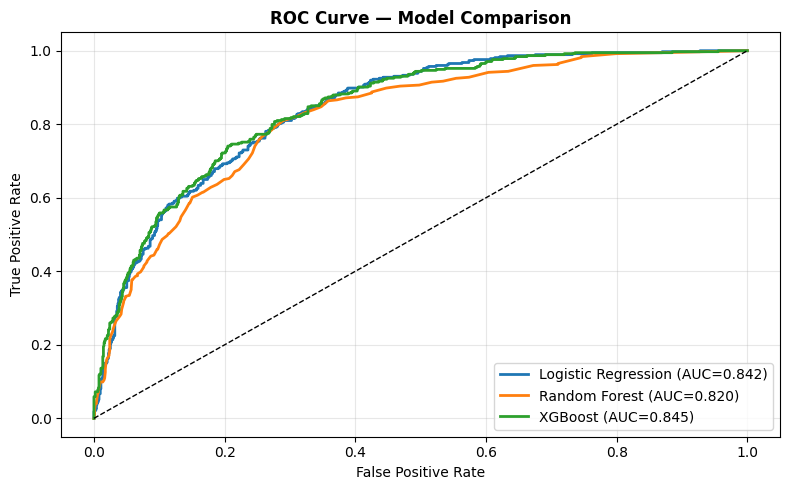

In [22]:
results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC'  : [round(lr_auc, 4), round(rf_auc, 4), round(xgb_auc, 4)],
    'F1 Score' : [round(lr_f1, 4),  round(rf_f1, 4),  round(xgb_f1, 4)]
}).sort_values('AUC-ROC', ascending=False)

print("=" * 44)
print("  MODEL COMPARISON")
print("=" * 44)
print(results.to_string(index=False))
print(f"\nBest model : {results.iloc[0]['Model']}")
print(f"Best AUC   : {results.iloc[0]['AUC-ROC']}")

# ROC curve — all 3 models
plt.figure(figsize=(8, 5))
for name, prob in [('Logistic Regression', lr_prob),
                   ('Random Forest', rf_prob),
                   ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

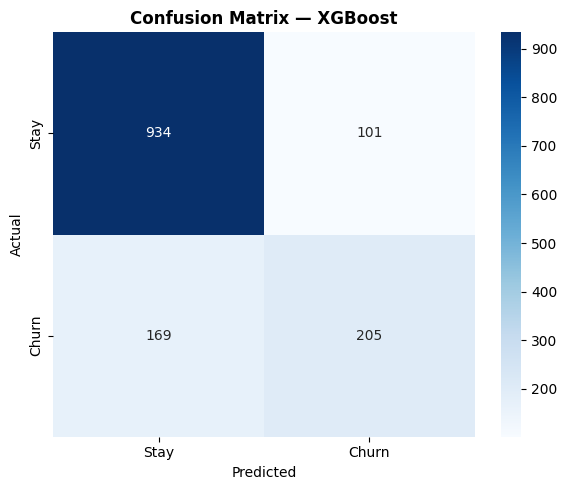

True Positives  (correctly caught churners) : 205
False Negatives (missed churners)           : 169
False Positives (wrongly flagged)           : 101
True Negatives  (correctly kept)            : 934


In [14]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix — XGBoost', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (correctly caught churners) : {tp}")
print(f"False Negatives (missed churners)           : {fn}")
print(f"False Positives (wrongly flagged)           : {fp}")
print(f"True Negatives  (correctly kept)            : {tn}")

In [23]:
# ── Threshold tuning ─────────────────────────────────────
# In churn: missing a churner (false negative) costs MORE
# than wrongly flagging a loyal customer (false positive)

thresholds = np.arange(0.3, 0.71, 0.05)
results_th = []

for th in thresholds:
    pred_th = (xgb_prob >= th).astype(int)
    f1_th   = f1_score(y_test, pred_th)
    cm_th   = confusion_matrix(y_test, pred_th)
    fn_th   = cm_th[1][0]   # missed churners
    fp_th   = cm_th[0][1]   # wrongly flagged loyal customers
    results_th.append({
        'Threshold'         : round(th, 2),
        'F1 Score'          : round(f1_th, 4),
        'Missed Churners'   : fn_th,
        'False Alarms'      : fp_th
    })

th_df = pd.DataFrame(results_th)
print("Threshold Tuning — XGBoost")
print(th_df.to_string(index=False))

best_th = th_df.loc[th_df['F1 Score'].idxmax(), 'Threshold']
print(f"\nBest threshold for F1 score : {best_th}")
print()
print("Business decision:")
print("  Default threshold = 0.50 — balanced")
print("  Lower threshold (0.35) = catch more churners, more false alarms")
print("  Recommended = 0.35 to minimise missed churners (revenue loss risk)")

Threshold Tuning — XGBoost
 Threshold  F1 Score  Missed Churners  False Alarms
      0.30    0.6275               86           256
      0.35    0.6395               99           211
      0.40    0.6190              127           177
      0.45    0.6082              152           134
      0.50    0.6029              169           101
      0.55    0.5525              203            74
      0.60    0.5096              228            53
      0.65    0.4229              263            40
      0.70    0.3903              277            26

Best threshold for F1 score : 0.35

Business decision:
  Default threshold = 0.50 — balanced
  Lower threshold (0.35) = catch more churners, more false alarms
  Recommended = 0.35 to minimise missed churners (revenue loss risk)


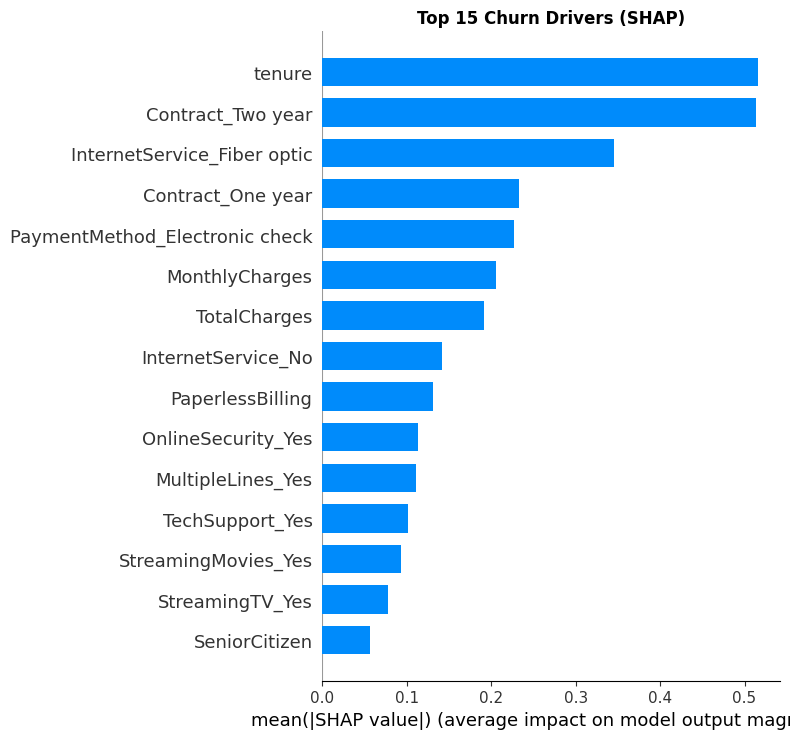

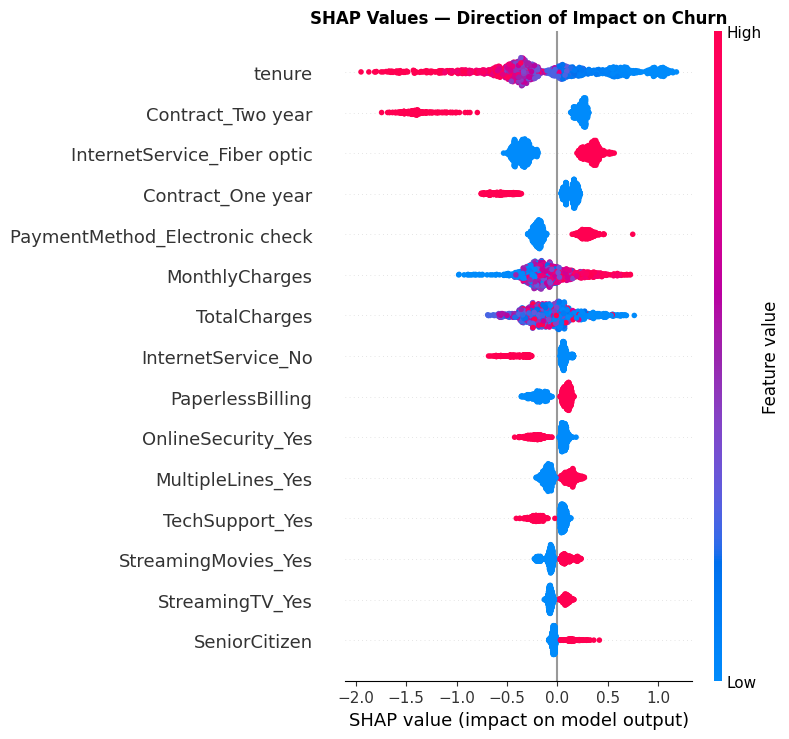

TOP 5 CHURN DRIVERS (note these for resume):
tenure                            0.516194
Contract_Two year                 0.514144
InternetService_Fiber optic       0.345648
Contract_One year                 0.232506
PaymentMethod_Electronic check    0.227021
dtype: float32


In [15]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Bar chart — which features matter most
plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('Top 15 Churn Drivers (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150)
plt.show()

# Dot plot — direction of impact
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title('SHAP Values — Direction of Impact on Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150)
plt.show()

# Print top 5 features — NOTE THESE FOR YOUR RESUME
feat_imp = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("TOP 5 CHURN DRIVERS (note these for resume):")
print(feat_imp.head(5))

In [16]:
raw2 = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw2['TotalCharges'] = pd.to_numeric(raw2['TotalCharges'], errors='coerce')

avg_monthly        = raw2['MonthlyCharges'].mean()
total_customers    = len(raw2)
churn_rate         = (raw2['Churn'] == 'Yes').mean()
churned_count      = int(total_customers * churn_rate)

# Top 20% highest predicted churn probability = high risk
threshold          = pd.Series(xgb_prob).quantile(0.80)
high_risk_n        = int((pd.Series(xgb_prob) >= threshold).sum())
annual_risk        = high_risk_n * avg_monthly * 12
revenue_saved      = annual_risk * 0.30

print("=" * 56)
print("  BUSINESS IMPACT REPORT")
print("=" * 56)
print(f"  Total customers           : {total_customers:,}")
print(f"  Churn rate                : {churn_rate*100:.1f}%")
print(f"  Churned customers         : {churned_count:,}")
print(f"  Avg monthly charge        : ${avg_monthly:.2f}")
print()
print(f"  High-risk customers (top 20%) : {high_risk_n:,}")
print(f"  Annual revenue at risk        : ${annual_risk:,.0f}")
print()
print(f"  If 30% retained via offers    : ${revenue_saved:,.0f} saved/year")
print()
print("  COPY THESE NUMBERS INTO YOUR RESUME BULLETS")
print("=" * 56)

  BUSINESS IMPACT REPORT
  Total customers           : 7,043
  Churn rate                : 26.5%
  Churned customers         : 1,869
  Avg monthly charge        : $64.76

  High-risk customers (top 20%) : 282
  Annual revenue at risk        : $219,154

  If 30% retained via offers    : $65,746 saved/year

  COPY THESE NUMBERS INTO YOUR RESUME BULLETS


In [24]:
# Model comparison table
results.to_csv('model_comparison.csv', index=False)

# Predictions with risk tiers
output = X_test.copy()
output['churn_probability'] = xgb_prob
output['predicted_churn']   = xgb_pred
output['actual_churn']      = y_test.values
output['risk_tier'] = pd.cut(
    xgb_prob,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
output.to_csv('churn_predictions.csv', index=False)

# SHAP feature importance
feat_imp_df = pd.DataFrame({
    'feature'          : X_test.columns,
    'shap_importance'  : np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)
feat_imp_df.to_csv('feature_importance_shap.csv', index=False)

print("Files saved:")
print("  model_comparison.csv")
print("  churn_predictions.csv")
print("  feature_importance_shap.csv")
print("  eda_overview.png")
print("  correlation_heatmap.png")
print("  roc_curve.png")
print("  shap_bar.png")
print("  shap_dot.png")
print("  confusion_matrix.png")
print()
print("Download from Colab Files panel (left sidebar)")
print("Upload to GitHub repo: customer-churn-prediction")

Files saved:
  model_comparison.csv
  churn_predictions.csv
  feature_importance_shap.csv
  eda_overview.png
  correlation_heatmap.png
  roc_curve.png
  shap_bar.png
  shap_dot.png
  confusion_matrix.png

Download from Colab Files panel (left sidebar)
Upload to GitHub repo: customer-churn-prediction
